
# 10 — Product Pulse Decision Engine

**Product Pulse**

The earlier notebooks built separate analytics and modeling capabilities:

- **Cookie Cats** → Did a product experiment improve user outcomes?
- **Retailrocket** → Who shows strong short-term purchase intent?
- **Online Retail II** → Which existing customers are likely to purchase again?
- **Criteo** → Which users are likely to convert *because of* an intervention?

This notebook adds the **decision layer**.

## Important design principle

These datasets represent different populations and different business problems.

We **do not merge their rows**.

Instead, Product Pulse treats them as independent decision modules behind one common decision interface.

```text
Experiment results ───────────────┐
                                  │
Short-term propensity ────────────┤
                                  ├──> Decision policies
Repeat-purchase propensity ───────┤
                                  │
Treatment uplift ─────────────────┘
```

The output is a set of reusable policy tables that explain:

- what question was answered,
- what evidence supports the decision,
- which users should be prioritized,
- what trade-off exists between targeting efficiency and coverage.


In [1]:

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = (
    Path.home()
    / "Desktop"
    / "resume_projects"
    / "ProductPulse"
)

RESULTS_ROOT = PROJECT_ROOT / "results"

RESULTS_05 = (
    RESULTS_ROOT
    / "05_cookie_cats_experiment_analysis"
    / "tables"
)

RESULTS_08 = (
    RESULTS_ROOT
    / "08_behavior_and_customer_prediction"
    / "tables"
)

RESULTS_09 = (
    RESULTS_ROOT
    / "09_criteo_uplift_modeling"
    / "tables"
)

RESULTS_10 = (
    RESULTS_ROOT
    / "10_product_pulse_decision_engine"
)

TABLES_DIR = RESULTS_10 / "tables"
FIGURES_DIR = RESULTS_10 / "figures"

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Project:", PROJECT_ROOT)
print("Decision-engine output:", RESULTS_10)


Project: /Users/noopur/Desktop/resume_projects/ProductPulse
Decision-engine output: /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine


## 1. Load the outputs produced by earlier notebooks

In [2]:

def read_required_csv(path):
    if not path.exists():
        raise FileNotFoundError(
            f"Required result not found:\n{path}\n"
            "Run the corresponding earlier notebook first."
        )

    return pd.read_csv(path)


# Notebook 05 — experiment analysis
experiment_conclusion = read_required_csv(
    RESULTS_05 / "experiment_conclusion.csv"
)

rounds_test = read_required_csv(
    RESULTS_05 / "rounds_test.csv"
)

# Notebook 08 — propensity models
rr_split_summary = read_required_csv(
    RESULTS_08 / "retailrocket_split_summary.csv"
)

rr_ranking = read_required_csv(
    RESULTS_08 / "retailrocket_selected_ranking.csv"
)

rr_selection = read_required_csv(
    RESULTS_08 / "retailrocket_model_selection.csv"
)

or_split_summary = read_required_csv(
    RESULTS_08 / "online_retail_split_summary.csv"
)

or_ranking = read_required_csv(
    RESULTS_08 / "online_retail_selected_ranking.csv"
)

or_selection = read_required_csv(
    RESULTS_08 / "online_retail_model_selection.csv"
)

# Notebook 09 — uplift model
uplift_targeting = read_required_csv(
    RESULTS_09 / "selected_test_targeting.csv"
)

uplift_selection = read_required_csv(
    RESULTS_09 / "model_selection.csv"
)

uplift_deciles = read_required_csv(
    RESULTS_09 / "uplift_deciles.csv"
)

print("Loaded all required upstream results.")


Loaded all required upstream results.



# 2. Decision module A — Product experiment

Cookie Cats asks a **product-policy question**, not a customer prediction question:

> Should the product use gate 30 or gate 40?

We use day-7 retention as the primary decision metric because the earlier experiment showed that the long-term retention effect is the clearest statistically significant outcome.

The decision rule is intentionally simple and auditable:

```text
significant improvement     → prefer gate_40
significant deterioration   → keep gate_30
not significant             → no clear winner
```


In [3]:

ret7 = (
    experiment_conclusion
    .loc[
        experiment_conclusion["metric"]
        == "retention_7"
    ]
    .iloc[0]
)

ret1 = (
    experiment_conclusion
    .loc[
        experiment_conclusion["metric"]
        == "retention_1"
    ]
    .iloc[0]
)

rounds = rounds_test.iloc[0]

ret7_diff = float(
    ret7[
        "absolute_difference_gate40_minus_gate30"
    ]
)

ret7_p = float(
    ret7["p_value"]
)

if (
    ret7_p < 0.05
    and ret7_diff > 0
):
    experiment_action = (
        "Prefer gate_40"
    )
    experiment_reason = (
        "Gate 40 significantly improves day-7 retention."
    )

elif (
    ret7_p < 0.05
    and ret7_diff < 0
):
    experiment_action = (
        "Keep gate_30"
    )
    experiment_reason = (
        "Gate 40 significantly reduces day-7 retention."
    )

else:
    experiment_action = (
        "No clear rollout winner"
    )
    experiment_reason = (
        "Day-7 retention difference is not statistically significant."
    )

experiment_decision = pd.DataFrame([{
    "module": "Product experimentation",
    "dataset": "Cookie Cats",
    "business_question": (
        "Should the game use gate_30 or gate_40?"
    ),
    "decision": experiment_action,
    "primary_metric": "day-7 retention",
    "gate_30_retention_pct": (
        100 * float(
            ret7["gate_30_rate"]
        )
    ),
    "gate_40_retention_pct": (
        100 * float(
            ret7["gate_40_rate"]
        )
    ),
    "difference_gate40_minus_gate30_pp": (
        100 * ret7_diff
    ),
    "p_value": ret7_p,
    "day1_difference_pp": (
        100
        * float(
            ret1[
                "absolute_difference_gate40_minus_gate30"
            ]
        )
    ),
    "game_round_mean_difference": float(
        rounds[
            "mean_difference_gate40_minus_gate30"
        ]
    ),
    "game_round_welch_p_value": float(
        rounds[
            "welch_t_p_value"
        ]
    ),
    "reason": experiment_reason,
}])

display(experiment_decision)


,module,dataset,business_question,decision,primary_metric,gate_30_retention_pct,gate_40_retention_pct,difference_gate40_minus_gate30_pp,p_value,day1_difference_pp,game_round_mean_difference,game_round_welch_p_value,reason
0,Product experimentation,Cookie Cats,Should the game use gate_30 or gate_40?,Keep gate_30,day-7 retention,19.020134,18.200004,-0.82013,0.001601,-0.590517,-1.157488,0.375924,Gate 40 significantly reduces day-7 retention.



# 3. Decision module B — Retailrocket short-term targeting

This module does **not** claim that contacting a visitor causes a purchase.

It answers:

> Which active visitors have the strongest short-term purchase propensity?

The correct use is **ranking and prioritization**.

We compare three candidate audience sizes:

- top 1%
- top 5%
- top 10%

For each policy we report:

- number of visitor/cutoff observations targeted,
- expected observed purchase incidence in that ranked audience,
- share of all future purchasers captured,
- lift relative to the overall purchase rate.


In [4]:

def test_row_count(split_summary):
    return int(
        split_summary.loc[
            split_summary["split"] == "test",
            "rows",
        ].iloc[0]
    )


def ranking_policy_table(
    ranking_row,
    test_rows,
    entity_name,
):
    rows = []

    for pct in [1, 5, 10]:
        fraction = pct / 100

        precision = float(
            ranking_row[
                f"precision_at_{pct}pct"
            ]
        )

        recall = float(
            ranking_row[
                f"recall_at_{pct}pct"
            ]
        )

        lift = float(
            ranking_row[
                f"lift_at_{pct}pct"
            ]
        )

        audience_rows = int(
            math.ceil(
                test_rows * fraction
            )
        )

        rows.append({
            "target_pct": pct,
            "target_fraction": fraction,
            "audience_rows": audience_rows,
            "observed_positive_rate": precision,
            "observed_positive_rate_pct": (
                100 * precision
            ),
            "captured_positive_share": recall,
            "captured_positive_share_pct": (
                100 * recall
            ),
            "lift_vs_population": lift,
            "estimated_positive_rows_in_audience": (
                audience_rows
                * precision
            ),
            "entity": entity_name,
        })

    return pd.DataFrame(rows)


rr_test_rows = test_row_count(
    rr_split_summary
)

rr_policy_options = ranking_policy_table(
    rr_ranking.iloc[0],
    rr_test_rows,
    "visitor prediction rows",
)

display(rr_policy_options)


,target_pct,target_fraction,audience_rows,observed_positive_rate,observed_positive_rate_pct,captured_positive_share,captured_positive_share_pct,lift_vs_population,estimated_positive_rows_in_audience,entity
0,1,0.01,6380,0.020376,2.037618,0.471014,47.101449,47.095838,130.0,visitor prediction rows
1,5,0.05,31897,0.005580,0.558046,0.644928,64.492754,12.898227,178.0,visitor prediction rows
2,10,0.10,63793,0.003104,0.310379,0.717391,71.739130,7.173846,198.0,visitor prediction rows


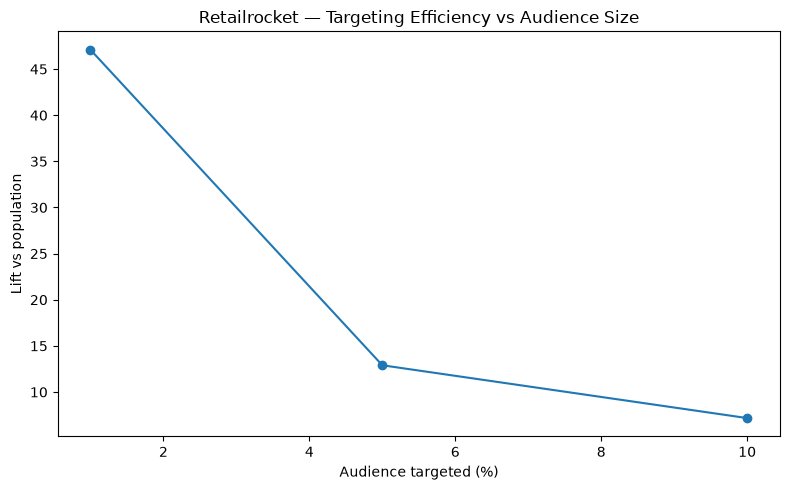

In [5]:

fig_rr_policy, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    rr_policy_options[
        "target_pct"
    ],
    rr_policy_options[
        "lift_vs_population"
    ],
    marker="o",
)

ax.set_xlabel(
    "Audience targeted (%)"
)
ax.set_ylabel(
    "Lift vs population"
)
ax.set_title(
    "Retailrocket — Targeting Efficiency vs Audience Size"
)

fig_rr_policy.tight_layout()
plt.show()



### How to use the Retailrocket policy

There is no universally correct audience size without intervention cost.

- A **small/high-cost** campaign should favor the highest-lift segment.
- A **broader/low-cost** campaign can target more users to capture a larger share of eventual purchasers.

The table therefore exposes the trade-off rather than inventing a marketing budget.



# 4. Decision module C — Online Retail repeat-purchase targeting

This model answers:

> Which existing customers are most likely to purchase again within 60 days?

As with Retailrocket, this is a **propensity** model, not a causal-treatment model.

The ranking can be used for prioritization such as:

- CRM outreach,
- loyalty messaging,
- account-management focus,
- customer-success prioritization.

We again compare top 1%, 5%, and 10% audiences.


In [6]:

or_test_rows = test_row_count(
    or_split_summary
)

or_policy_options = ranking_policy_table(
    or_ranking.iloc[0],
    or_test_rows,
    "customer prediction rows",
)

display(or_policy_options)


,target_pct,target_fraction,audience_rows,observed_positive_rate,observed_positive_rate_pct,captured_positive_share,captured_positive_share_pct,lift_vs_population,estimated_positive_rows_in_audience,entity
0,1,0.01,57,1.000000,100.000000,0.020263,2.026306,1.992890,57.0,customer prediction rows
1,5,0.05,281,0.964413,96.441281,0.096338,9.633843,1.921969,271.0,customer prediction rows
2,10,0.10,561,0.910873,91.087344,0.181657,18.165659,1.815271,511.0,customer prediction rows


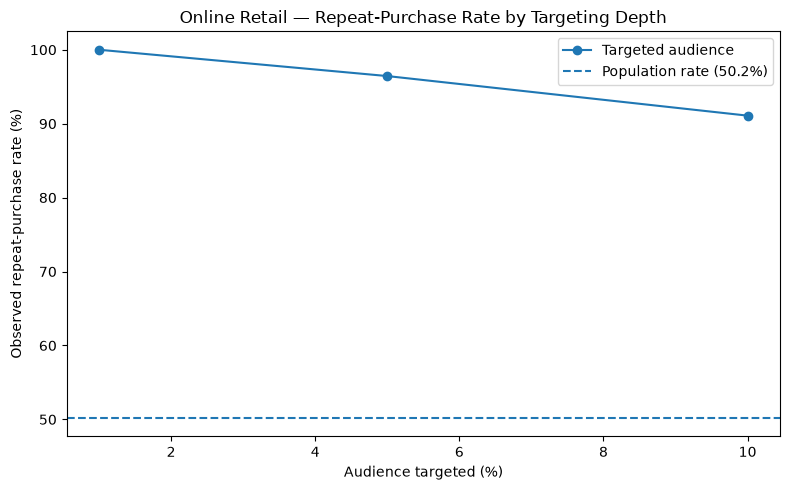

In [7]:

fig_or_policy, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    or_policy_options[
        "target_pct"
    ],
    or_policy_options[
        "observed_positive_rate_pct"
    ],
    marker="o",
    label="Targeted audience",
)

population_rate_pct = (
    100
    * float(
        or_ranking.iloc[0][
            "population_positive_rate"
        ]
    )
)

ax.axhline(
    population_rate_pct,
    linestyle="--",
    label=(
        f"Population rate "
        f"({population_rate_pct:.1f}%)"
    ),
)

ax.set_xlabel(
    "Audience targeted (%)"
)
ax.set_ylabel(
    "Observed repeat-purchase rate (%)"
)
ax.set_title(
    "Online Retail — Repeat-Purchase Rate by Targeting Depth"
)
ax.legend()

fig_or_policy.tight_layout()
plt.show()



# 5. Decision module D — Criteo causal targeting

This module answers the strongest decision question in Product Pulse:

> Who should receive the intervention because the intervention is expected to improve their conversion outcome?

This is different from propensity ranking.

For each possible audience size we calculate:

- observed treatment uplift,
- incremental conversions per 10,000 targeted users,
- approximate incremental conversions if that entire test-set audience were treated.

The last quantity is a test-set policy estimate, not a future-production guarantee.


In [8]:

causal_policy = uplift_targeting.copy()

causal_policy[
    "incremental_conversions_per_10k"
] = (
    causal_policy[
        "observed_uplift"
    ]
    * 10_000
)

causal_policy[
    "estimated_incremental_conversions_in_audience"
] = (
    causal_policy[
        "observed_uplift"
    ]
    * causal_policy[
        "rows"
    ]
)

causal_policy[
    "conversion_uplift_relative_to_population"
] = (
    causal_policy[
        "observed_uplift"
    ]
    / causal_policy.loc[
        causal_policy[
            "target_fraction"
        ] == 1.0,
        "observed_uplift",
    ].iloc[0]
)

display(causal_policy)


,target_fraction,target_pct,rows,treated_rows,control_rows,treated_conversion_rate,control_conversion_rate,observed_uplift,observed_uplift_pp,incremental_conversions_per_10k,estimated_incremental_conversions_in_audience,conversion_uplift_relative_to_population
0,0.01,1.0,20779,18339,2440,0.138666,0.107787,0.030879,3.087935,308.793452,641.641914,26.471152
1,0.05,5.0,103891,90454,13437,0.044940,0.031108,0.013832,1.383184,138.318352,1437.003194,11.857266
2,0.10,10.0,207781,179545,28236,0.025208,0.016858,0.008350,0.835025,83.502532,1735.023960,7.158209
3,0.20,20.0,415561,356356,59205,0.013719,0.008901,0.004818,0.481815,48.181514,2002.235818,4.130334
4,1.00,100.0,2077801,1765503,312298,0.003120,0.001953,0.001167,0.116653,11.665282,2423.813464,1.000000


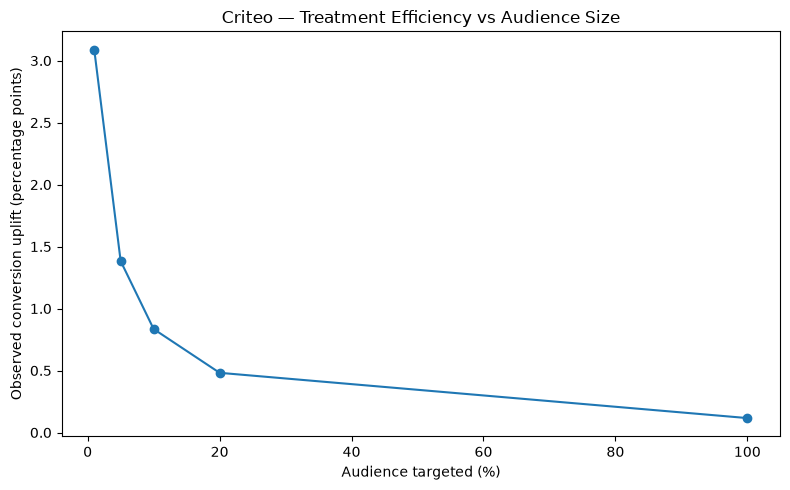

In [9]:

fig_uplift_policy, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    causal_policy[
        "target_pct"
    ],
    causal_policy[
        "observed_uplift_pp"
    ],
    marker="o",
)

ax.set_xlabel(
    "Audience targeted (%)"
)
ax.set_ylabel(
    "Observed conversion uplift (percentage points)"
)
ax.set_title(
    "Criteo — Treatment Efficiency vs Audience Size"
)

fig_uplift_policy.tight_layout()
plt.show()



### Causal targeting trade-off

The uplift model separates two objectives:

**Efficiency**

```text
How much incremental conversion do we get per targeted user?
```

This usually favors the smallest, highest-uplift audience.

**Total incremental impact**

```text
How many additional conversions could the intervention generate overall?
```

This may favor a larger audience even if per-user uplift is lower.

The correct policy depends on intervention cost, capacity, and conversion value.



# 6. Common Product Pulse decision registry

The four modules now share a common interface.

The registry is deliberately **not a row-level join**.

It describes the decision capability supplied by each dataset/model.


In [10]:

rr_model = (
    rr_selection.iloc[0][
        "selected_model"
    ]
)

or_model = (
    or_selection.iloc[0][
        "selected_model"
    ]
)

uplift_model = (
    uplift_selection.iloc[0][
        "selected_model"
    ]
)

decision_registry = pd.DataFrame([
    {
        "module": "Experimentation",
        "dataset": "Cookie Cats",
        "decision_unit": "Product variant",
        "question": (
            "Should gate_40 replace gate_30?"
        ),
        "method": (
            "Randomized A/B test"
        ),
        "primary_output": (
            experiment_action
        ),
        "causal": True,
    },
    {
        "module": "Short-term conversion propensity",
        "dataset": "Retailrocket",
        "decision_unit": (
            "Visitor at prediction time"
        ),
        "question": (
            "Who is most likely to transact "
            "within 7 days?"
        ),
        "method": rr_model,
        "primary_output": (
            "transaction_propensity_score"
        ),
        "causal": False,
    },
    {
        "module": "Repeat-purchase propensity",
        "dataset": "Online Retail II",
        "decision_unit": (
            "Customer at prediction time"
        ),
        "question": (
            "Who is most likely to purchase "
            "again within 60 days?"
        ),
        "method": or_model,
        "primary_output": (
            "repeat_purchase_probability"
        ),
        "causal": False,
    },
    {
        "module": "Treatment uplift",
        "dataset": "Criteo Uplift",
        "decision_unit": "User",
        "question": (
            "Whose conversion probability "
            "is most improved by treatment?"
        ),
        "method": uplift_model,
        "primary_output": "uplift_score",
        "causal": True,
    },
])

display(decision_registry)


,module,dataset,decision_unit,question,method,primary_output,causal
0,Experimentation,Cookie Cats,Product variant,Should gate_40 replace gate_30?,Randomized A/B test,Keep gate_30,True
1,Short-term conversion propensity,Retailrocket,Visitor at prediction time,Who is most likely to transact within 7 days?,HistGradientBoosting,transaction_propensity_score,False
2,Repeat-purchase propensity,Online Retail II,Customer at prediction time,Who is most likely to purchase again within 60...,HistGradientBoosting,repeat_purchase_probability,False
3,Treatment uplift,Criteo Uplift,User,Whose conversion probability is most improved ...,LogisticRegression_TLearner,uplift_score,True



# 7. Business-facing decision cards

These cards summarize what a downstream service or dashboard would expose.

They intentionally distinguish **prediction** from **causal impact**.


In [11]:

rr_best_lift = (
    rr_policy_options
    .sort_values(
        "lift_vs_population",
        ascending=False,
    )
    .iloc[0]
)

or_top_10 = (
    or_policy_options
    .loc[
        or_policy_options[
            "target_pct"
        ] == 10
    ]
    .iloc[0]
)

criteo_top_10 = (
    causal_policy
    .loc[
        causal_policy[
            "target_pct"
        ] == 10
    ]
    .iloc[0]
)

decision_cards = pd.DataFrame([
    {
        "capability": "Experiment decision",
        "headline": experiment_action,
        "evidence": (
            f"Gate 40 vs gate 30 day-7 retention "
            f"difference = "
            f"{experiment_decision.iloc[0]['difference_gate40_minus_gate30_pp']:.3f} pp; "
            f"p={experiment_decision.iloc[0]['p_value']:.4f}"
        ),
        "interpretation": (
            "Randomized experiment supports a product-level decision."
        ),
    },
    {
        "capability": "Short-term visitor prioritization",
        "headline": (
            f"Top {int(rr_best_lift['target_pct'])}% "
            f"has {rr_best_lift['lift_vs_population']:.2f}x "
            "purchase lift"
        ),
        "evidence": (
            f"Captures "
            f"{rr_best_lift['captured_positive_share_pct']:.1f}% "
            "of observed future purchasers at that targeting depth."
        ),
        "interpretation": (
            "Use as propensity ranking; it does not prove outreach causes purchases."
        ),
    },
    {
        "capability": "Repeat-purchase prioritization",
        "headline": (
            f"Top 10% repeat-purchase rate = "
            f"{or_top_10['observed_positive_rate_pct']:.1f}%"
        ),
        "evidence": (
            f"Lift vs customer population = "
            f"{or_top_10['lift_vs_population']:.2f}x."
        ),
        "interpretation": (
            "Prioritizes likely repeat customers; it is not an uplift estimate."
        ),
    },
    {
        "capability": "Causal treatment targeting",
        "headline": (
            f"Top 10% observed treatment uplift = "
            f"{criteo_top_10['observed_uplift_pp']:.3f} pp"
        ),
        "evidence": (
            f"Equivalent to about "
            f"{criteo_top_10['incremental_conversions_per_10k']:.1f} "
            "incremental conversions per 10,000 targeted users "
            "in the test experiment."
        ),
        "interpretation": (
            "Use uplift ranking when deciding who should receive an intervention."
        ),
    },
])

display(decision_cards)


,capability,headline,evidence,interpretation
0,Experiment decision,Keep gate_30,Gate 40 vs gate 30 day-7 retention difference ...,Randomized experiment supports a product-level...
1,Short-term visitor prioritization,Top 1% has 47.10x purchase lift,Captures 47.1% of observed future purchasers a...,Use as propensity ranking; it does not prove o...
2,Repeat-purchase prioritization,Top 10% repeat-purchase rate = 91.1%,Lift vs customer population = 1.82x.,Prioritizes likely repeat customers; it is not...
3,Causal treatment targeting,Top 10% observed treatment uplift = 0.835 pp,Equivalent to about 83.5 incremental conversio...,Use uplift ranking when deciding who should re...



# 8. Guardrails for production use

The decision layer should enforce several rules:

1. **Do not merge the four public datasets into one customer table.**
2. **Do not interpret propensity as causality.**
3. **Do not use test labels in live decisions.**
4. **Choose targeting depth using business cost/capacity, not only model metrics.**
5. **Monitor positive rates, lift, uplift, and feature distributions over time.**
6. **Re-estimate treatment effects when the intervention or population changes.**
7. **Keep model version, data version, and policy version together.**


In [12]:

guardrails = pd.DataFrame([
    {
        "guardrail": (
            "Separate populations"
        ),
        "reason": (
            "Retailrocket, Online Retail, "
            "Cookie Cats, and Criteo are "
            "different datasets and cannot "
            "be joined as the same users."
        ),
    },
    {
        "guardrail": (
            "Propensity is not causality"
        ),
        "reason": (
            "High likelihood to purchase does "
            "not prove an intervention caused "
            "the purchase."
        ),
    },
    {
        "guardrail": (
            "Untouched test evaluation"
        ),
        "reason": (
            "Policy and model selection must "
            "come from train/validation data."
        ),
    },
    {
        "guardrail": (
            "Budget-aware targeting"
        ),
        "reason": (
            "Audience size should depend on "
            "intervention cost and capacity."
        ),
    },
    {
        "guardrail": (
            "Monitor drift"
        ),
        "reason": (
            "Performance can change as customer "
            "behavior and treatment response change."
        ),
    },
])

display(guardrails)


,guardrail,reason
0,Separate populations,"Retailrocket, Online Retail, Cookie Cats, and ..."
1,Propensity is not causality,High likelihood to purchase does not prove an ...
2,Untouched test evaluation,Policy and model selection must come from trai...
3,Budget-aware targeting,Audience size should depend on intervention co...
4,Monitor drift,Performance can change as customer behavior an...


## 9. Save decision-engine outputs

In [13]:

RESULT_TABLES = {
    "experiment_decision": experiment_decision,
    "retailrocket_targeting_policy": rr_policy_options,
    "online_retail_targeting_policy": or_policy_options,
    "criteo_causal_targeting_policy": causal_policy,
    "decision_registry": decision_registry,
    "decision_cards": decision_cards,
    "production_guardrails": guardrails,
}

RESULT_FIGURES = {
    "retailrocket_targeting_tradeoff": fig_rr_policy,
    "online_retail_targeting_tradeoff": fig_or_policy,
    "criteo_uplift_targeting_tradeoff": fig_uplift_policy,
}

for name, table in RESULT_TABLES.items():
    table.to_csv(
        TABLES_DIR / f"{name}.csv",
        index=False,
    )

for name, fig in RESULT_FIGURES.items():
    fig.savefig(
        FIGURES_DIR / f"{name}.png",
        dpi=200,
        bbox_inches="tight",
    )

print("=" * 72)
print("NOTEBOOK 10 COMPLETE")
print("=" * 72)

print("\nTables saved:")
for name in RESULT_TABLES:
    print(
        " -",
        TABLES_DIR / f"{name}.csv"
    )

print("\nFigures saved:")
for name in RESULT_FIGURES:
    print(
        " -",
        FIGURES_DIR / f"{name}.png"
    )


NOTEBOOK 10 COMPLETE

Tables saved:
 - /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine/tables/experiment_decision.csv
 - /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine/tables/retailrocket_targeting_policy.csv
 - /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine/tables/online_retail_targeting_policy.csv
 - /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine/tables/criteo_causal_targeting_policy.csv
 - /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine/tables/decision_registry.csv
 - /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine/tables/decision_cards.csv
 - /Users/noopur/Desktop/resume_projects/ProductPulse/results/10_product_pulse_decision_engine/tables/production_guardrails.csv

Figures saved:
 - /Users/noopur/Desktop/resume_project